In [ ]:
!pip install -q -U datasets huggingface_hub pandas matplotlib rich pymupdf rapidfuzz tqdm

import json, re, textwrap, random, math
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from huggingface_hub import hf_hub_download, list_repo_files
from rapidfuzz import fuzz
import fitz

console = Console()
DATASET_ID = "llamaindex/ParseBench"
WORKDIR = Path("/content/parsebench_tutorial")
WORKDIR.mkdir(parents=True, exist_ok=True)

console.print(Panel.fit("Advanced ParseBench Tutorial on Google Colab", style="bold green"))

files = list_repo_files(DATASET_ID, repo_type="dataset")
jsonl_files = [f for f in files if f.endswith(".jsonl")]
pdf_files = [f for f in files if f.endswith(".pdf")]

console.print(f"Found {len(jsonl_files)} JSONL files")
console.print(f"Found {len(pdf_files)} PDF files")

table = Table(title="ParseBench JSONL Files")
table.add_column("File")
table.add_column("Dimension")
for f in jsonl_files:
    table.add_row(f, Path(f).stem)
console.print(table)

In [ ]:
def load_jsonl_from_hf(filename, max_rows=None):
    path = hf_hub_download(repo_id=DATASET_ID, filename=filename, repo_type="dataset")
    rows = []
    with open(path, "r", encoding="utf-8") as fp:
        for i, line in enumerate(fp):
            if max_rows and i >= max_rows:
                break
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows, path

def flatten_dict(d, parent_key="", sep="."):
    items = {}
    if isinstance(d, dict):
        for k, v in d.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
            if isinstance(v, dict):
                items.update(flatten_dict(v, new_key, sep=sep))
            else:
                items[new_key] = v
    return items

dimension_data = {}
for jf in jsonl_files:
    rows, local_path = load_jsonl_from_hf(jf)
    dimension_data[Path(jf).stem] = rows
    console.print(f"{jf}: {len(rows)} examples loaded")

summary_rows = []
for dim, rows in dimension_data.items():
    keys = Counter()
    for r in rows[:100]:
        keys.update(flatten_dict(r).keys())
    summary_rows.append({
        "dimension": dim,
        "examples": len(rows),
        "top_fields": ", ".join([k for k, _ in keys.most_common(12)])
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

plt.figure(figsize=(10, 5))
plt.bar(summary_df["dimension"], summary_df["examples"])
plt.title("ParseBench Examples by Dimension")
plt.xlabel("Dimension")
plt.ylabel("Number of Examples")
plt.xticks(rotation=30, ha="right")
plt.show()

for dim, rows in dimension_data.items():
    console.print(Panel.fit(f"Sample schema for {dim}", style="bold cyan"))
    if rows:
        console.print(json.dumps(rows[0], indent=2)[:3000])

In [ ]:
all_records = []
for dim, rows in dimension_data.items():
    for i, r in enumerate(rows):
        flat = flatten_dict(r)
        flat["_dimension"] = dim
        flat["_row_id"] = i
        all_records.append(flat)

df = pd.DataFrame(all_records)
console.print(f"Combined dataframe shape: {df.shape}")
display(df.head())

missing_report = []
for col in df.columns:
    missing_report.append({
        "column": col,
        "non_null": int(df[col].notna().sum()),
        "missing": int(df[col].isna().sum()),
        "coverage_pct": round(100 * df[col].notna().mean(), 2)
    })

missing_df = pd.DataFrame(missing_report).sort_values("coverage_pct", ascending=False)
display(missing_df.head(40))

def find_candidate_columns(df, keywords):
    cols = []
    for c in df.columns:
        lc = c.lower()
        if any(k.lower() in lc for k in keywords):
            cols.append(c)
    return cols

doc_cols = find_candidate_columns(df, ["doc", "pdf", "file", "path", "source", "image"])
text_cols = find_candidate_columns(df, ["text", "content", "markdown", "ground", "answer", "expected", "target", "reference"])
rule_cols = find_candidate_columns(df, ["rule", "check", "assert", "criteria", "question", "prompt"])
bbox_cols = find_candidate_columns(df, ["bbox", "box", "polygon", "coordinates", "layout"])

console.print("[bold]Possible document columns:[/bold]", doc_cols[:30])
console.print("[bold]Possible text/reference columns:[/bold]", text_cols[:30])
console.print("[bold]Possible rule/question columns:[/bold]", rule_cols[:30])
console.print("[bold]Possible layout columns:[/bold]", bbox_cols[:30])

In [ ]:
def pick_first_existing(row, candidates):
    for c in candidates:
        if c in row and pd.notna(row[c]):
            value = row[c]
            if isinstance(value, str) and value.strip():
                return value
            if not isinstance(value, str):
                return value
    return None

def normalize_text(x):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x)
    return x.strip().lower()

def simple_text_similarity(a, b):
    a = normalize_text(a)
    b = normalize_text(b)
    if not a or not b:
        return None
    return fuzz.token_set_ratio(a, b) / 100

def locate_pdf_path(value):
    if value is None:
        return None
    value = str(value)
    candidates = []
    if value.endswith(".pdf"):
        candidates.append(value)
        candidates.extend([f for f in pdf_files if f.endswith(value.split("/")[-1])])
    else:
        candidates.extend([
            f for f in pdf_files
            if value in f or Path(f).stem in value or value in Path(f).stem
        ])
    return candidates[0] if candidates else None

def extract_pdf_text_from_hf(pdf_repo_path, max_pages=2):
    local_pdf = hf_hub_download(repo_id=DATASET_ID, filename=pdf_repo_path, repo_type="dataset")
    doc = fitz.open(local_pdf)
    texts = []
    for page_idx in range(min(max_pages, len(doc))):
        texts.append(doc[page_idx].get_text("text"))
    doc.close()
    return "\n".join(texts), local_pdf

def render_pdf_first_page(pdf_repo_path, zoom=2):
    local_pdf = hf_hub_download(repo_id=DATASET_ID, filename=pdf_repo_path, repo_type="dataset")
    doc = fitz.open(local_pdf)
    page = doc[0]
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    out_path = WORKDIR / (Path(pdf_repo_path).stem + "_page1.png")
    pix.save(out_path)
    doc.close()
    return out_path

sample_records = df.sample(min(25, len(df)), random_state=42).to_dict("records")
pdf_candidates = []

for row in sample_records:
    for c in doc_cols:
        pdf_path = locate_pdf_path(row.get(c))
        if pdf_path:
            pdf_candidates.append((row["_dimension"], row["_row_id"], pdf_path))
            break

pdf_candidates = list(dict.fromkeys(pdf_candidates))
console.print(f"Detected {len(pdf_candidates)} PDF-linked sampled records")

if pdf_candidates:
    dim, row_id, pdf_path = pdf_candidates[0]
    console.print(Panel.fit(f"Rendering sample PDF\nDimension: {dim}\nRow: {row_id}\nPDF: {pdf_path}", style="bold yellow"))
    image_path = render_pdf_first_page(pdf_path)
    img = plt.imread(image_path)
    plt.figure(figsize=(10, 12))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{dim}: {Path(pdf_path).name}")
    plt.show()
else:
    console.print("[yellow]No PDF-linked rows were detected from the sample.[/yellow]")

In [ ]:
preferred_gt_cols = [
    c for c in text_cols
    if any(k in c.lower() for k in ["ground", "expected", "target", "answer", "content", "text", "markdown", "reference"])
]

evaluation_rows = []
eval_sample = df.sample(min(50, len(df)), random_state=7).to_dict("records")

for row in tqdm(eval_sample, desc="Running lightweight PDF text extraction baseline"):
    pdf_path = None
    for c in doc_cols:
        pdf_path = locate_pdf_path(row.get(c))
        if pdf_path:
            break

    if not pdf_path:
        evaluation_rows.append({
            "dimension": row.get("_dimension"),
            "row_id": row.get("_row_id"),
            "pdf": None,
            "ground_truth_column": None,
            "similarity_score": None,
            "status": "no_pdf_detected"
        })
        continue

    gt_col = None
    gt = None
    for c in preferred_gt_cols:
        if c in row and pd.notna(row[c]):
            gt_col = c
            gt = row[c]
            break

    if gt is None:
        evaluation_rows.append({
            "dimension": row.get("_dimension"),
            "row_id": row.get("_row_id"),
            "pdf": pdf_path,
            "ground_truth_column": None,
            "similarity_score": None,
            "status": "no_reference_detected"
        })
        continue

    try:
        extracted, local_pdf = extract_pdf_text_from_hf(pdf_path, max_pages=2)
        score = simple_text_similarity(extracted, gt)
        evaluation_rows.append({
            "dimension": row.get("_dimension"),
            "row_id": row.get("_row_id"),
            "pdf": pdf_path,
            "ground_truth_column": gt_col,
            "similarity_score": score,
            "extracted_chars": len(extracted),
            "ground_truth_chars": len(str(gt)),
            "status": "scored"
        })
    except Exception as e:
        evaluation_rows.append({
            "dimension": row.get("_dimension"),
            "row_id": row.get("_row_id"),
            "pdf": pdf_path,
            "ground_truth_column": gt_col,
            "similarity_score": None,
            "status": "error",
            "error": str(e)
        })

eval_df = pd.DataFrame(evaluation_rows)

if eval_df.empty:
    eval_df = pd.DataFrame(columns=[
        "dimension", "row_id", "pdf", "ground_truth_column",
        "similarity_score", "extracted_chars", "ground_truth_chars",
        "status", "error"
    ])

display(eval_df.head(30))

if "status" in eval_df.columns:
    display(eval_df["status"].value_counts().reset_index().rename(columns={"index": "status", "status": "count"}))

if not eval_df.empty and "similarity_score" in eval_df.columns:
    valid_eval = eval_df.dropna(subset=["similarity_score"])

    if len(valid_eval):
        console.print(f"Average lightweight text similarity: {valid_eval['similarity_score'].mean():.3f}")

        plt.figure(figsize=(8, 5))
        plt.hist(valid_eval["similarity_score"], bins=10)
        plt.title("Lightweight Baseline Similarity Distribution")
        plt.xlabel("RapidFuzz Token Set Similarity")
        plt.ylabel("Count")
        plt.show()

        per_dim = valid_eval.groupby("dimension")["similarity_score"].mean().reset_index()
        display(per_dim)

        plt.figure(figsize=(9, 5))
        plt.bar(per_dim["dimension"], per_dim["similarity_score"])
        plt.title("Average Baseline Similarity by Dimension")
        plt.xlabel("Dimension")
        plt.ylabel("Average Similarity")
        plt.xticks(rotation=30, ha="right")
        plt.show()
    else:
        console.print("[yellow]No valid similarity scores were produced. This usually means sampled rows did not contain both detectable PDFs and reference text.[/yellow]")
else:
    console.print("[yellow]No similarity_score column found.[/yellow]")

╭──────────────────────────────────────────────╮
│ Advanced ParseBench Tutorial on Google Colab │
╰──────────────────────────────────────────────╯

Found 5 JSONL files

Found 2037 PDF files

          ParseBench JSONL Files           
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ File                  ┃ Dimension       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ chart.jsonl           │ chart           │
│ layout.jsonl          │ layout          │
│ table.jsonl           │ table           │
│ text_content.jsonl    │ text_content    │
│ text_formatting.jsonl │ text_formatting │
└───────────────────────┴─────────────────┘

chart.jsonl: 4864 examples loaded

layout.jsonl: 16325 examples loaded

table.jsonl: 503 examples loaded

text_content.jsonl: 141322 examples loaded

text_formatting.jsonl: 5997 examples loaded

,dimension,examples,top_fields
0,chart,4864,"pdf, category, id, type, rule, page, expected_..."
1,layout,16325,"pdf, category, id, type, rule, page, expected_..."
2,table,503,"pdf, category, id, type, rule, page, expected_..."
3,text_content,141322,"pdf, category, id, type, rule, page, expected_..."
4,text_formatting,5997,"pdf, category, id, type, rule, page, expected_..."


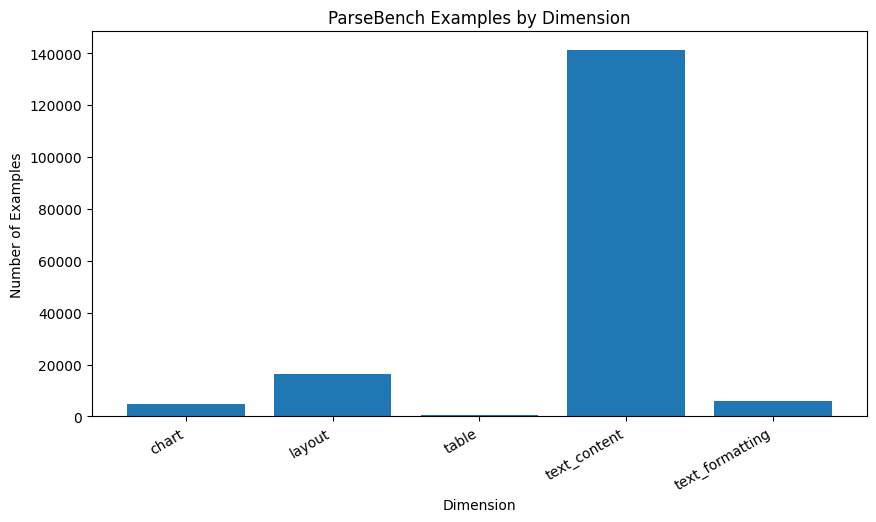

╭─────────────────────────╮
│ Sample schema for chart │
╰─────────────────────────╯

{
  "pdf": "docs/chart/(Web_version)_E-Government_Survey_2024_1392024_p101.pdf",
  "category": "chart",
  "id": "b17e5e98d6fc2763",
  "type": "chart_data_point",
  "rule": "{\"labels\": [\"IF\", \"193 UN Member States\"], \"max_diffs\": 0, \"normalize_numbers\": true, 
\"value\": \"0.8079\"}",
  "page": null,
  "expected_markdown": null,
  "tags": []
}

╭──────────────────────────╮
│ Sample schema for layout │
╰──────────────────────────╯

{
  "pdf": "docs/layout/0000050863-25-000054_p7.pdf",
  "category": "layout",
  "id": "04cdeb289e5e8eab",
  "type": "layout",
  "rule": "{\"attributes\": {\"title_level\": \"title\"}, \"bbox\": [0.03921425423971037, 0.07471938714748476, 
0.5943319776581555, 0.027988355683117368], \"canonical_class\": \"Section\", \"content\": {\"text\": \"Meeting 
Notice and Voting Roadmap\", \"type\": \"text\"}, \"ro_index\": 0, \"source_label\": \"paragraph_title\"}",
  "page": 1,
  "expected_markdown": null,
  "tags": [
    "hard"
  ]
}

╭─────────────────────────╮
│ Sample schema for table │
╰─────────────────────────╯

...

Possible text/reference columns:
['expected_markdown']

Possible rule/question columns:
['rule']

Possible layout columns:
[]

Detected 25 PDF-linked sampled records

╭────────────────────────────────────╮
│ Rendering sample PDF               │
│ Dimension: text_content            │
│ Row: 71076                         │
│ PDF: docs/text/text_ocr__admnh.pdf │
╰────────────────────────────────────╯

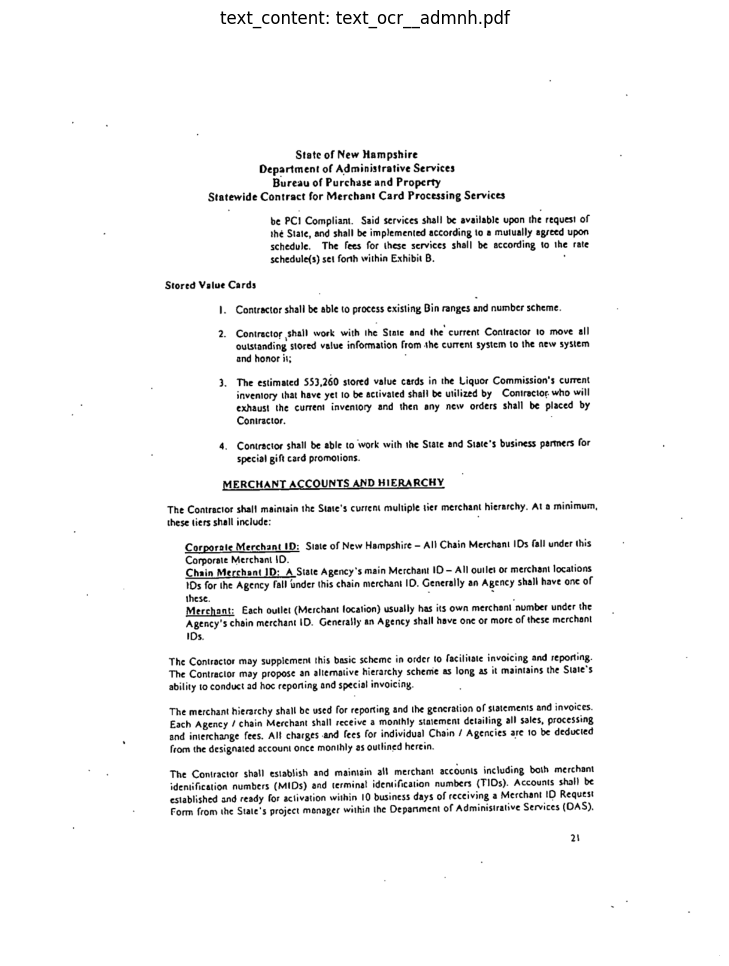

Running lightweight PDF text extraction baseline:   0%|          | 0/50 [00:00<?, ?it/s]

,dimension,row_id,pdf,ground_truth_column,similarity_score,status
0,text_content,138082,docs/text/text_simple__textinsquare.pdf,None,None,no_reference_detected
1,text_content,141288,docs/text/text_sparse__numbers.pdf,None,None,no_reference_detected
2,text_content,114332,docs/text/text_simple__endnote.pdf,None,None,no_reference_detected
3,text_content,140825,docs/text/text_simple__yell.pdf,None,None,no_reference_detected
4,text_content,3050,docs/text/text_dense__legalRef.pdf,None,None,no_reference_detected
5,text_content,135331,docs/text/text_simple__spaceing.pdf,None,None,no_reference_detected
6,text_content,75825,docs/text/text_ocr__dhaka.pdf,None,None,no_reference_detected
7,text_content,139455,docs/text/text_simple__whiteonyellow.pdf,None,None,no_reference_detected
8,text_content,70614,docs/text/text_ocr__abstract.pdf,None,None,no_reference_detected
9,text_content,44924,docs/text/text_multicolumns__long2cols.pdf,None,None,no_reference_detected


,count,count
0,no_reference_detected,50


No valid similarity scores were produced. This usually means sampled rows did not contain both detectable PDFs and 
reference text.

╭─────────────────────────────╮
│ Inspecting chart: 4864 rows │
╰─────────────────────────────╯

...

╭──────────────────────────────────────────────────────────╮
│ Example prompt for testing an external OCR or VLM parser │
╰──────────────────────────────────────────────────────────╯

You are evaluating a document parser on ParseBench.

Dimension:
layout

Task:
Parse the PDF page into a structured representation that preserves the information needed for agentic workflows.

Relevant benchmark hint or rule:
{"attributes": {"text_role": "footnote", "furniture": "page-footer"}, "bbox": [0.10623705608088796, 
0.9573189786585367, 0.2352313009122523, 0.008980147198932826], "canonical_class": "Text", "content": {"text": 
"Indicates an alternative performance measure\n", "type": "text"}, "ro_index": 58, "source_label": "footer"}

Reference field preview:
No obvious reference field detected.

Return:
1. Markdown representation
2. Extracted tables as JSON arrays when tables exist
3. Extracted chart values as JSON when charts exist
4. Layout-sensitive notes when visual grounding matters

No valid similarity scores were available for best/worst comparison.

Saved flattened sample to: /content/parsebench_tutorial/parsebench_flattened_sample.csv

╭────────────────────────────────────────────────────────────────────────────╮
│                                                                            │
│ Tutorial complete.                                                         │
│                                                                            │
│ What we build:                                                             │
│ 1. Load ParseBench files directly from Hugging Face.                       │
│ 2. Inspect benchmark dimensions and schemas.                               │
│ 3. Flatten records into a dataframe.                                       │
│ 4. Detect linked PDFs and render sample pages when possible.               │
│ 5. Run a lightweight PyMuPDF extraction baseline.                          │
│ 6. Score extracted text when reference fields are available.               │
│ 7. Generate reusable prompts for OCR, VLM, and document parser evaluation. │
│                                                                            │
╰────────────────────────────────────────────────────────────────────────────╯

In [2]:
def inspect_dimension(dimension_name, n=3):
    rows = dimension_data.get(dimension_name, [])
    console.print(Panel.fit(f"Inspecting {dimension_name}: {len(rows)} rows", style="bold magenta"))
    for idx, row in enumerate(rows[:n]):
        console.print(f"\n[bold]Example {idx}[/bold]")
        console.print(json.dumps(row, indent=2)[:2500])

for dim in list(dimension_data.keys())[:5]:
    inspect_dimension(dim, n=1)

def make_parsebench_subset(dimension=None, n=20, seed=123):
    subset = df.copy()
    if dimension:
        subset = subset[subset["_dimension"] == dimension]
    if len(subset) == 0:
        return subset
    return subset.sample(min(n, len(subset)), random_state=seed)

subset = make_parsebench_subset(n=20)
display(subset.head())

def create_llm_parser_prompt(row):
    dimension = row.get("_dimension", "unknown")
    candidate_truth = pick_first_existing(row, preferred_gt_cols)
    rule_hint = pick_first_existing(row, rule_cols)

    prompt = f"""
You are evaluating a document parser on ParseBench.

Dimension:
{dimension}

Task:
Parse the PDF page into a structured representation that preserves the information needed for agentic workflows.

Relevant benchmark hint or rule:
{rule_hint if rule_hint is not None else "No obvious rule field detected."}

Reference field preview:
{str(candidate_truth)[:1000] if candidate_truth is not None else "No obvious reference field detected."}

Return:
1. Markdown representation
2. Extracted tables as JSON arrays when tables exist
3. Extracted chart values as JSON when charts exist
4. Layout-sensitive notes when visual grounding matters
"""
    return textwrap.dedent(prompt).strip()

prompt_examples = []
if len(subset):
    for _, row in subset.head(3).iterrows():
        prompt_examples.append(create_llm_parser_prompt(row.to_dict()))

if prompt_examples:
    console.print(Panel.fit("Example prompt for testing an external OCR or VLM parser", style="bold blue"))
    console.print(prompt_examples[0])
else:
    console.print("[yellow]No prompt examples could be created because the subset is empty.[/yellow]")

def compare_parser_outputs(reference, candidate):
    return {
        "token_set_similarity": simple_text_similarity(reference, candidate),
        "partial_ratio": fuzz.partial_ratio(normalize_text(reference), normalize_text(candidate)) / 100 if reference and candidate else None,
        "candidate_length": len(str(candidate)) if candidate else 0,
        "reference_length": len(str(reference)) if reference else 0
    }

if not eval_df.empty and "similarity_score" in eval_df.columns:
    scored_eval = eval_df.dropna(subset=["similarity_score"])

    if len(scored_eval):
        best = scored_eval.sort_values("similarity_score", ascending=False).head(1)
        worst = scored_eval.sort_values("similarity_score", ascending=True).head(1)

        console.print(Panel.fit("Best lightweight baseline example", style="bold green"))
        display(best)

        console.print(Panel.fit("Worst lightweight baseline example", style="bold red"))
        display(worst)
    else:
        console.print("[yellow]No valid similarity scores were available for best/worst comparison.[/yellow]")

output_path = WORKDIR / "parsebench_flattened_sample.csv"
df.head(500).to_csv(output_path, index=False)
console.print(f"Saved flattened sample to: {output_path}")

console.print(Panel.fit("""
Tutorial complete.

What we build:
1. Load ParseBench files directly from Hugging Face.
2. Inspect benchmark dimensions and schemas.
3. Flatten records into a dataframe.
4. Detect linked PDFs and render sample pages when possible.
5. Run a lightweight PyMuPDF extraction baseline.
6. Score extracted text when reference fields are available.
7. Generate reusable prompts for OCR, VLM, and document parser evaluation.
""", style="bold green"))